# Step 2 — Clean the Tracks

Inspect the cleaning that was done by `etl.ipynb`.
Verify data quality: no outliers, correct timestamps, valid coordinates.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

BASE_DIR  = Path("../noel_part")
CLEAN_DIR = BASE_DIR / "cleaned_data_final"

steps   = [d for d in CLEAN_DIR.iterdir() if d.is_dir()]
flights = [f for s in steps for f in s.iterdir() if f.is_dir()]
print(f"Flights available: {len(flights)}")

Flights available: 2149


## 2a. Check for coordinate validity

In [2]:
from pyproj import Geod
geod = Geod(ellps="WGS84")

issues = []
for flight_dir in flights[:50]:
    for fname in ["adsb_before.parquet", "adsb_after.parquet", "adsc.parquet"]:
        try:
            df = pd.read_parquet(flight_dir / fname)
            bad_lat = ~df["latitude"].between(-90, 90)
            bad_lon = ~df["longitude"].between(-180, 180)
            if bad_lat.any() or bad_lon.any():
                issues.append({"flight": flight_dir.name, "file": fname,
                               "bad_rows": int(bad_lat.sum() + bad_lon.sum())})
        except: continue

if issues:
    print(f"Flights with invalid coordinates: {len(issues)}")
    display(pd.DataFrame(issues))
else:
    print("✓ All coordinates valid in checked flights")

✓ All coordinates valid in checked flights


## 2b. Check for physically unrealistic speeds

In [3]:
MAX_SPEED_KTS = 800.0

speed_issues = []
for flight_dir in flights[:50]:
    for fname in ["adsb_before.parquet", "adsb_after.parquet"]:
        try:
            df = pd.read_parquet(flight_dir / fname).sort_values("timestamp").reset_index(drop=True)
            if len(df) < 2: continue
            for i in range(1, len(df)):
                dt = (df["timestamp"].iloc[i] - df["timestamp"].iloc[i-1]).total_seconds()
                if dt <= 0: continue
                _,_,d = geod.inv(float(df["longitude"].iloc[i-1]), float(df["latitude"].iloc[i-1]),
                                 float(df["longitude"].iloc[i]),   float(df["latitude"].iloc[i]))
                spd = abs(d) / dt * 1.94384
                if spd > MAX_SPEED_KTS:
                    speed_issues.append({"flight": flight_dir.name, "file": fname,
                                         "speed_kts": round(spd,1)})
        except: continue

if speed_issues:
    print(f"Speed anomalies found: {len(speed_issues)}")
    display(pd.DataFrame(speed_issues).head(10))
else:
    print(f"✓ No speeds above {MAX_SPEED_KTS} kts in checked flights")

Speed anomalies found: 916


,flight,file,speed_kts
0,20230810_4ba959_073209_092245,adsb_before.parquet,1183.8
1,20230810_4ba959_073209_092245,adsb_after.parquet,909.7
2,20230810_4ba959_073209_092245,adsb_after.parquet,1012.7
3,20230810_4ba959_073209_092245,adsb_after.parquet,1363.7
4,20230810_4ba959_073209_092245,adsb_after.parquet,2494.0
5,20230810_4ba959_073209_092245,adsb_after.parquet,1249.4
6,20230810_4ba959_073209_092245,adsb_after.parquet,2267.9
7,20230810_4ba959_073209_092245,adsb_after.parquet,2553.3
8,20230810_4ba959_073209_092245,adsb_after.parquet,957.9
9,20230810_4ba959_073209_092245,adsb_after.parquet,1217.6


## 2c. Gap duration distribution

Gap statistics (minutes):
  Min    : 31.2
  Median : 234.5
  Mean   : 242.9
  Max    : 604.2


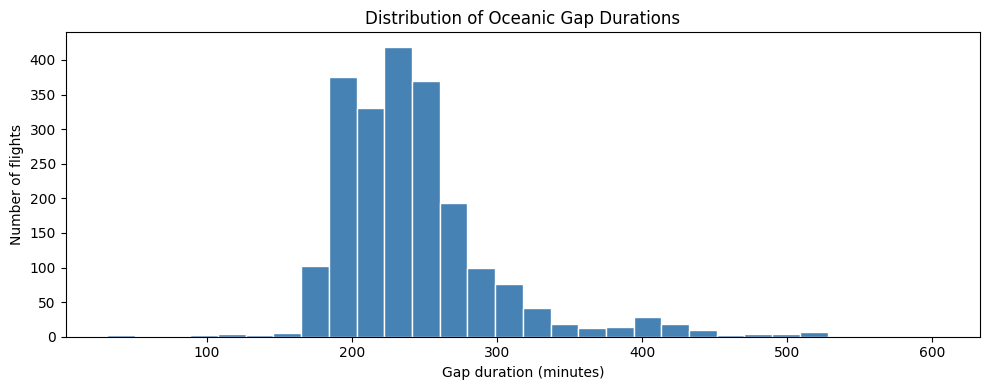

In [4]:
import matplotlib.pyplot as plt

gaps = []
for flight_dir in flights:
    try:
        b = pd.read_parquet(flight_dir / "adsb_before.parquet")
        a = pd.read_parquet(flight_dir / "adsb_after.parquet")
        gap = (a["timestamp"].min() - b["timestamp"].max()).total_seconds() / 60
        gaps.append(gap)
    except: continue

gaps = np.array(gaps)
print(f"Gap statistics (minutes):")
print(f"  Min    : {gaps.min():.1f}")
print(f"  Median : {np.median(gaps):.1f}")
print(f"  Mean   : {gaps.mean():.1f}")
print(f"  Max    : {gaps.max():.1f}")

plt.figure(figsize=(10, 4))
plt.hist(gaps, bins=30, color="steelblue", edgecolor="white")
plt.xlabel("Gap duration (minutes)")
plt.ylabel("Number of flights")
plt.title("Distribution of Oceanic Gap Durations")
plt.tight_layout()
plt.show()